In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as pl
from matplotlib import rcParams
import scanpy as sc

import scipy
import numpy as np
import matplotlib.pyplot as plt
import warnings

warnings.simplefilter(action="ignore", category=Warning)

# verbosity: errors (0), warnings (1), info (2), hints (3)
sc.settings.verbosity = 3
sc.settings.set_figure_params(dpi=100, frameon=False, figsize=(5, 5), facecolor='white', color_map = 'viridis_r') 

import os
import subprocess

# download pre-computed data if missing or long compute
fetch_data = True

# url for source and intermediate data
path_data = "https://nextcloud.dc.scilifelab.se/public.php/webdav"
curl_upass = "zbC5fr2LbEZ9rSE:scRNAseq2025"

path_results = "data/trajectory"
if not os.path.exists(path_results):
    os.makedirs(path_results, exist_ok=True)

path_file = "data/trajectory/trajectory_seurat_filtered.h5ad"
if not os.path.exists(path_file):
    file_url = os.path.join(path_data, "trajectory/trajectory_seurat_filtered.h5ad")
    subprocess.call(["curl", "-u", curl_upass, "-o", path_file, file_url ])    

In [2]:
adata = sc.read_h5ad("data/trajectory/trajectory_seurat_filtered.h5ad")

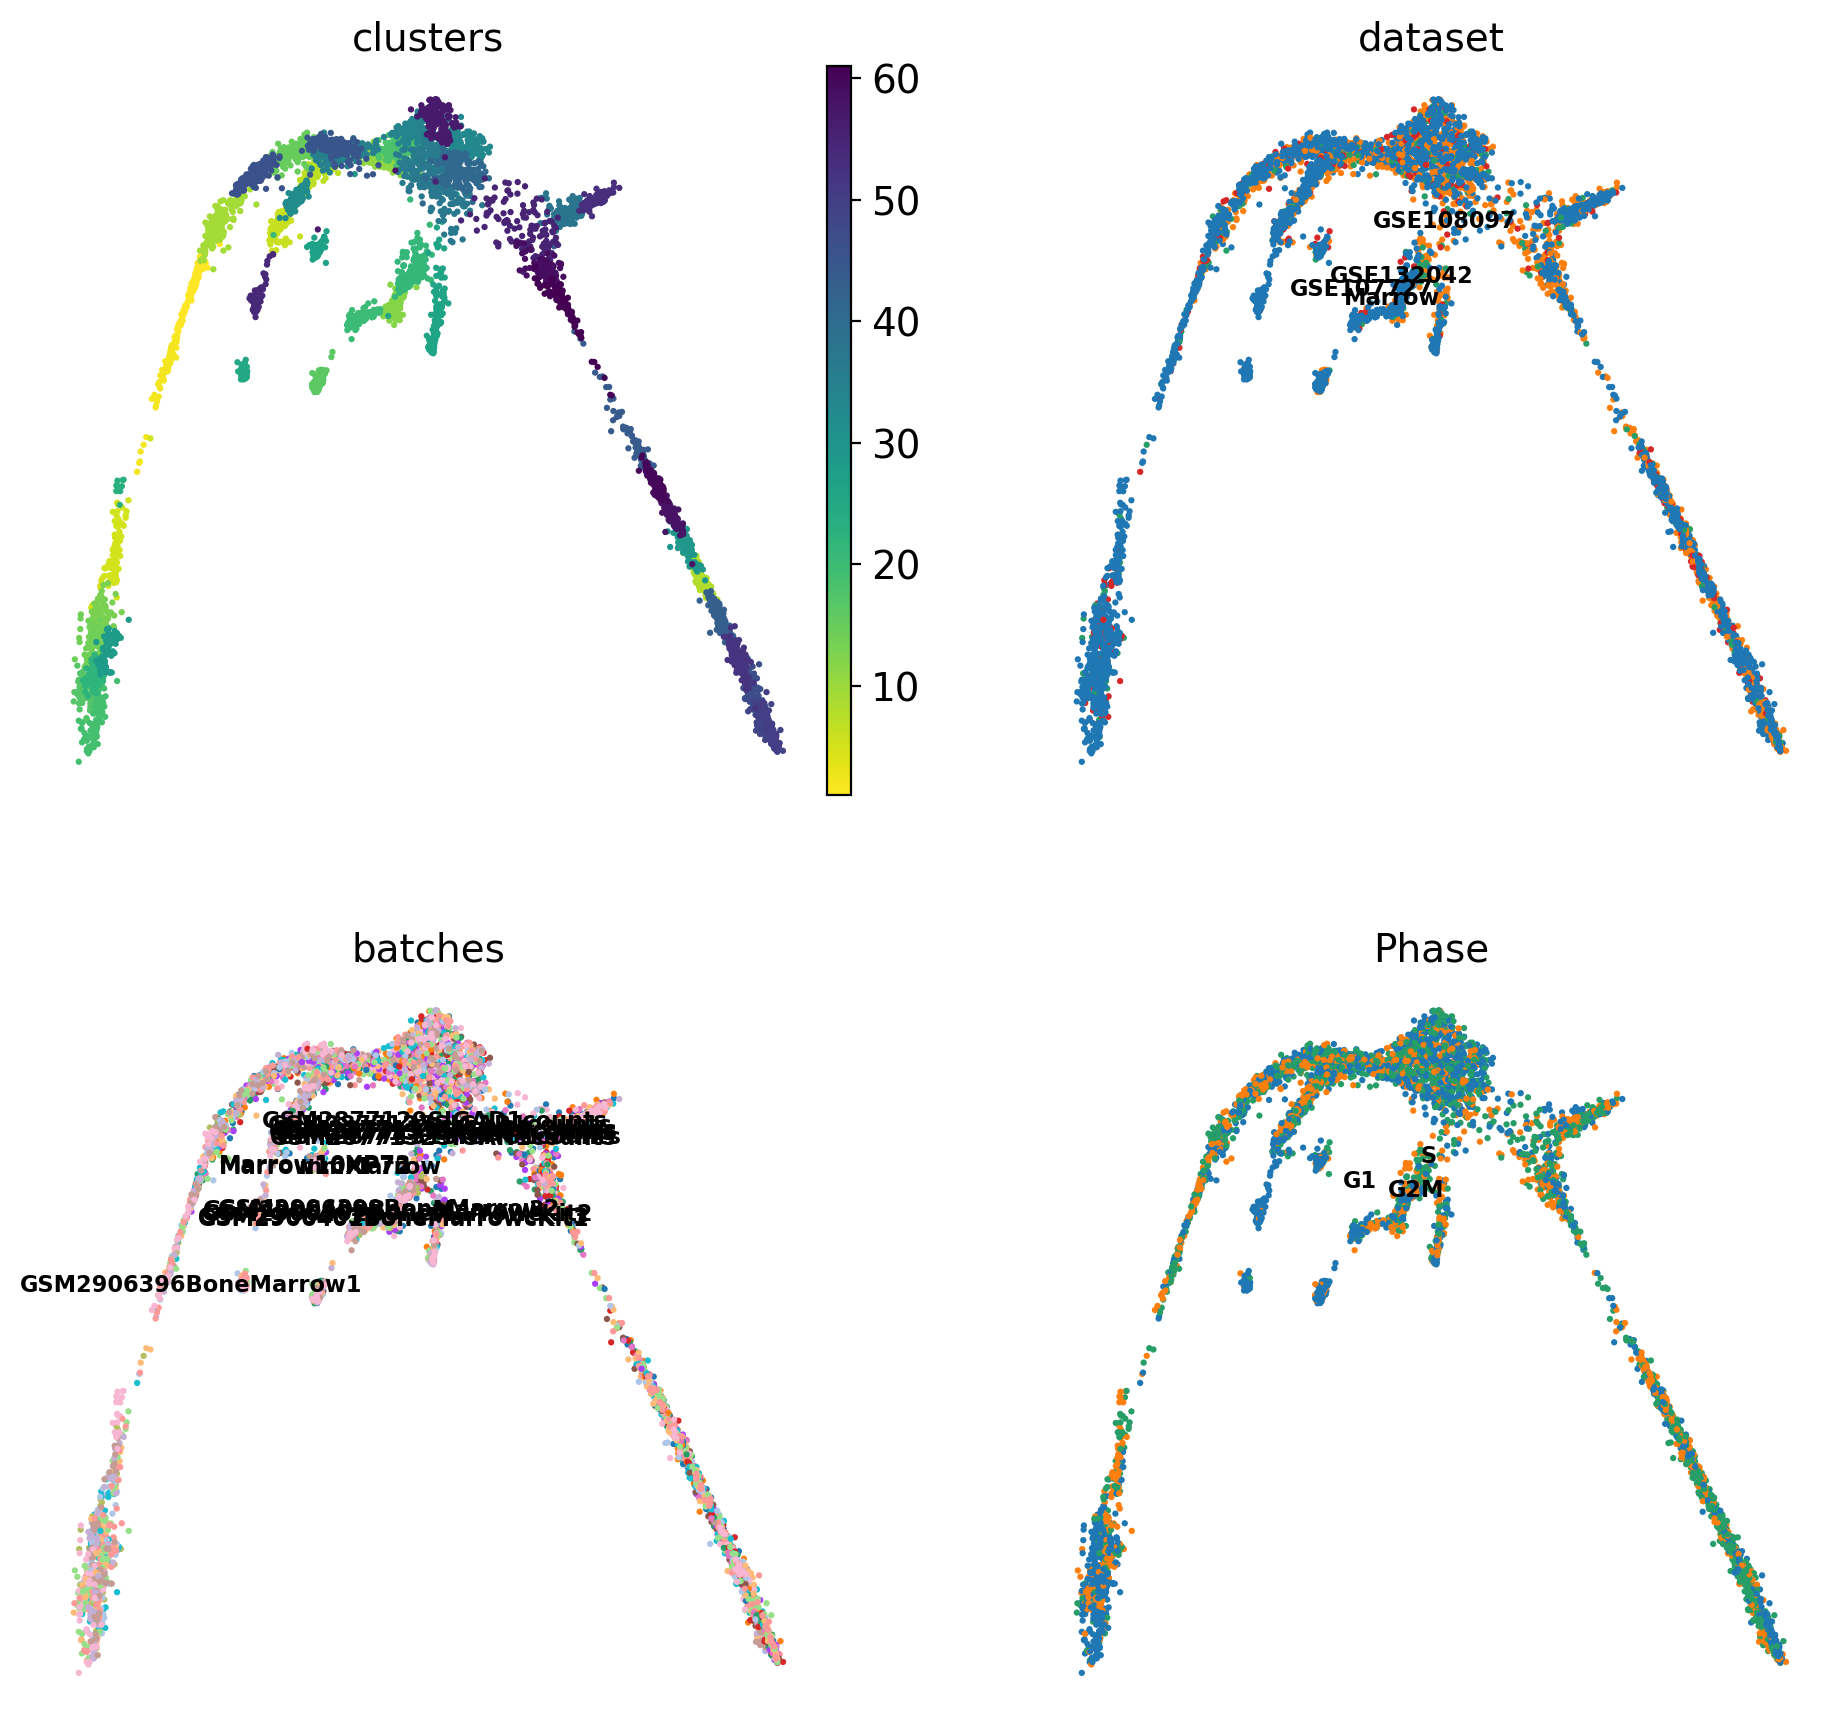

In [3]:
sc.pl.umap(adata, color = ['clusters','dataset','batches','Phase'],legend_loc = 'on data', legend_fontsize = 'xx-small', ncols = 2)

In [4]:
# first, store the old umap with a new name so it is not overwritten
adata.obsm['X_umap_old'] = adata.obsm['X_umap']

sc.pp.neighbors(adata, n_pcs = 30, n_neighbors = 20, use_rep="X_harmony_Phase")
sc.tl.umap(adata, min_dist=0.4, spread=3)

computing neighbors
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:06)
computing UMAP
    finished: added
    'X_umap', UMAP coordinates (adata.obsm)
    'umap', UMAP parameters (adata.uns) (0:00:07)


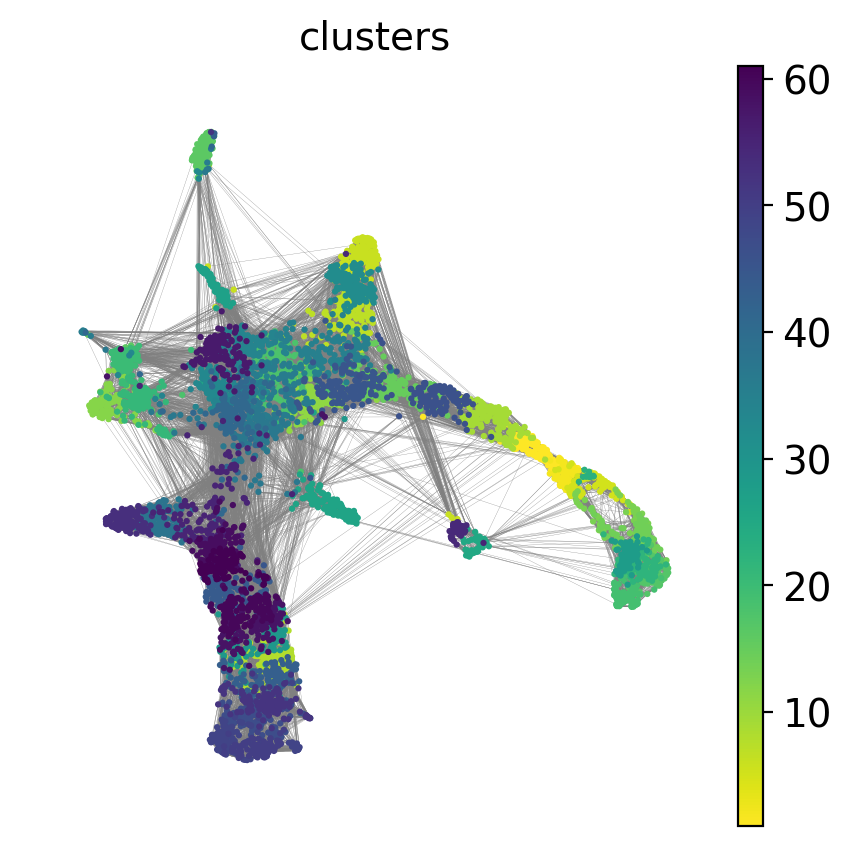

running Leiden clustering
    finished: found 16 clusters and added
    'leiden_1.0', the cluster labels (adata.obs, categorical) (0:00:02)
running Leiden clustering
    finished: found 17 clusters and added
    'leiden_1.2', the cluster labels (adata.obs, categorical) (0:00:01)
running Leiden clustering
    finished: found 19 clusters and added
    'leiden_1.4', the cluster labels (adata.obs, categorical) (0:00:02)


In [5]:
sc.pl.umap(adata, color = ['clusters'],legend_loc = 'on data', legend_fontsize = 'xx-small', edges = True)

# Redo clustering as well
sc.tl.leiden(adata, key_added = "leiden_1.0", resolution = 1.0) # default resolution in 1.0
sc.tl.leiden(adata, key_added = "leiden_1.2", resolution = 1.2) # default resolution in 1.0
sc.tl.leiden(adata, key_added = "leiden_1.4", resolution = 1.4) # default resolution in 1.0

#sc.tl.louvain(adata, key_added = "leiden_1.0") # default resolution in 1.0

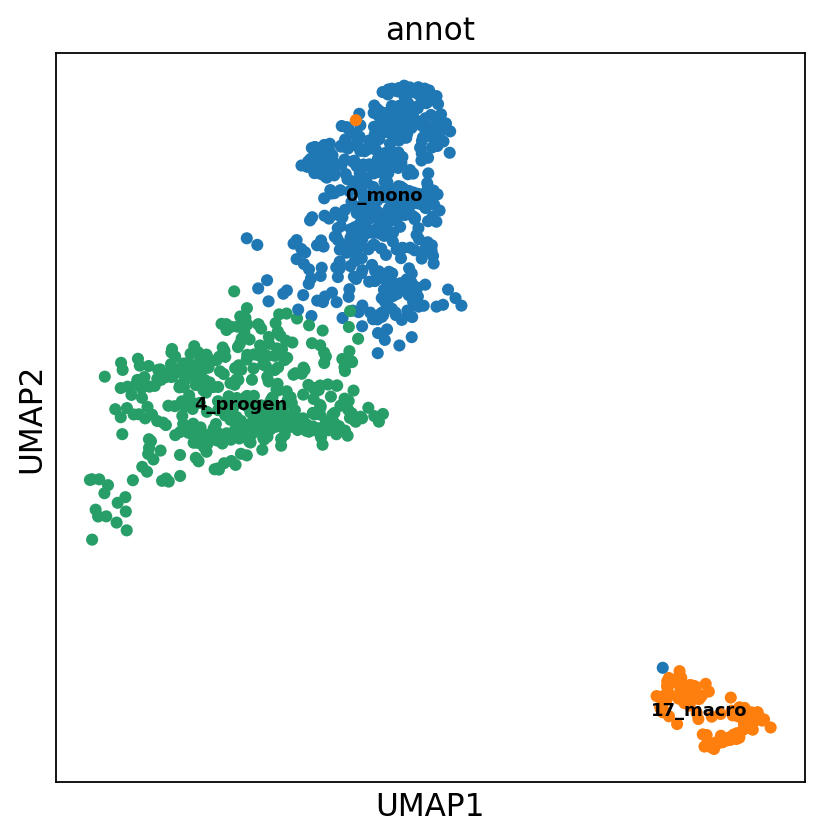

In [33]:
#Rename clusters with really clear markers, the rest are left unlabelled.

annot = pd.DataFrame(adata.obs['leiden_1.4'].astype('string'))
annot[annot['leiden_1.4'] == '10'] = '10_megakaryo' #Pf4
annot[annot['leiden_1.4'] == '17'] = '17_macro'  #C1qc
annot[annot['leiden_1.4'] == '11'] = '11_eryth' #Alas2
annot[annot['leiden_1.4'] == '18'] = '18_dend' #Siglech
annot[annot['leiden_1.4'] == '13'] = '13_mast' #Mcpt8
annot[annot['leiden_1.4'] == '0'] = '0_mono' #Cts3
annot[annot['leiden_1.4'] == '1'] = '1_gran' #Ltf
annot[annot['leiden_1.4'] == '9'] = '9_gran'
annot[annot['leiden_1.4'] == '14'] = '14_TC' #Cd3e
annot[annot['leiden_1.4'] == '16'] = '16_BC' #Ms4a1
annot[annot['leiden_1.4'] == '8'] = '8_progen'  # Cd34
annot[annot['leiden_1.4'] == '4'] = '4_progen' 
annot[annot['leiden_1.4'] == '5'] = '5_progen'

adata.obs['annot']=annot['leiden_1.4'].astype('category')

clusters = [
    '4_progen',
    '0_mono',
    '17_macro'
]

adata = adata[adata.obs['annot'].isin(clusters)].copy()


sc.pl.umap(adata, color = 'annot',legend_loc = 'on data', legend_fontsize = 'xx-small', ncols =2)

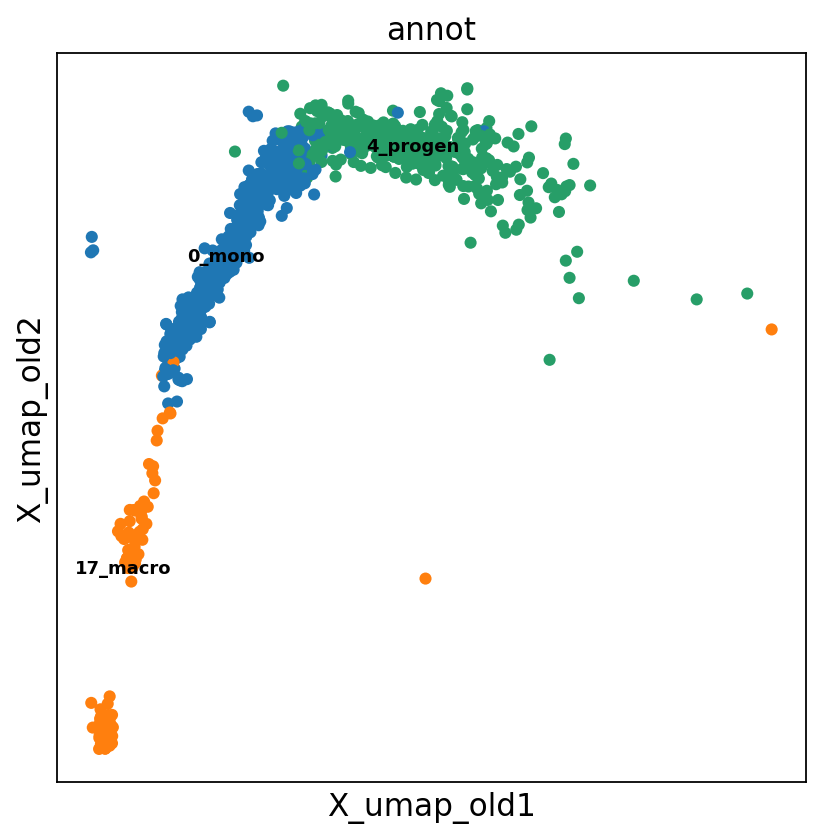

In [34]:
# plot onto the Seurat embedding:
sc.pl.embedding(adata, basis='X_umap_old', color = 'annot',legend_loc = 'on data', legend_fontsize = 'xx-small', ncols =2)

running PAGA
    finished: added
    'paga/connectivities', connectivities adjacency (adata.uns)
    'paga/connectivities_tree', connectivities subtree (adata.uns) (0:00:00)


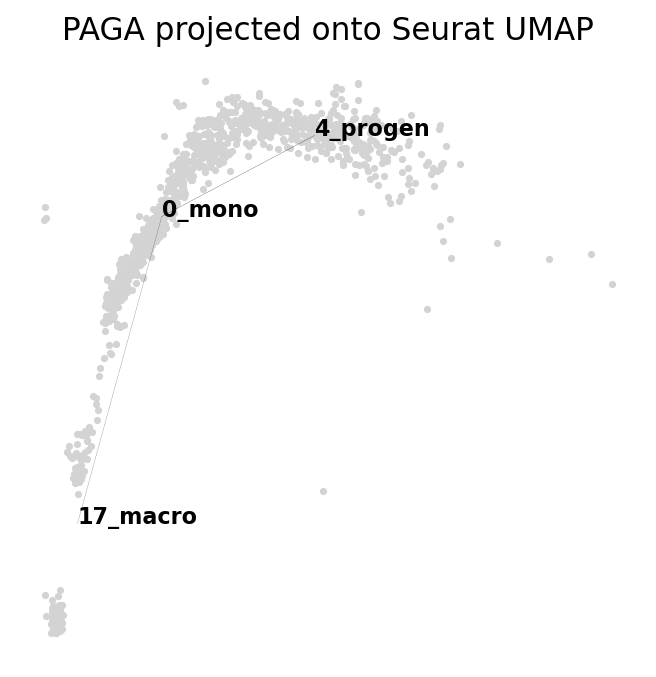

In [35]:
import numpy as np
import matplotlib.pyplot as plt

# 1) PAGA 계산
sc.tl.paga(adata, groups='annot')

# 2) Seurat UMAP 좌표 가져오기
X = adata.obsm['X_umap_old']

# 3) 노드별 평균 좌표 계산
# 각 label(annot)에 해당하는 점들의 중심(centroid)을 만든다
groups = adata.obs['annot'].cat.categories
centroids = np.vstack([X[adata.obs['annot'] == g].mean(axis=0) for g in groups])

# 4) 플롯 시작
plt.figure(figsize=(5,5))

# (1) point scatter
plt.scatter(X[:,0], X[:,1], s=5, c='lightgray')

# (2) paga edges overlay
conn = adata.uns['paga']['connectivities'].todense()
for i in range(conn.shape[0]):
    for j in range(i+1, conn.shape[1]):
        if conn[i,j] > 0:
            x1, y1 = centroids[i]
            x2, y2 = centroids[j]
            plt.plot([x1, x2], [y1, y2],
                     linewidth=2 * float(conn[i,j]),
                     color='black', alpha=0.8)

# (3) node labels
for i, g in enumerate(groups):
    x,y = centroids[i]
    plt.text(x, y, g, fontsize=10, weight='bold')

plt.title("PAGA projected onto Seurat UMAP")
plt.axis('off')
plt.show()


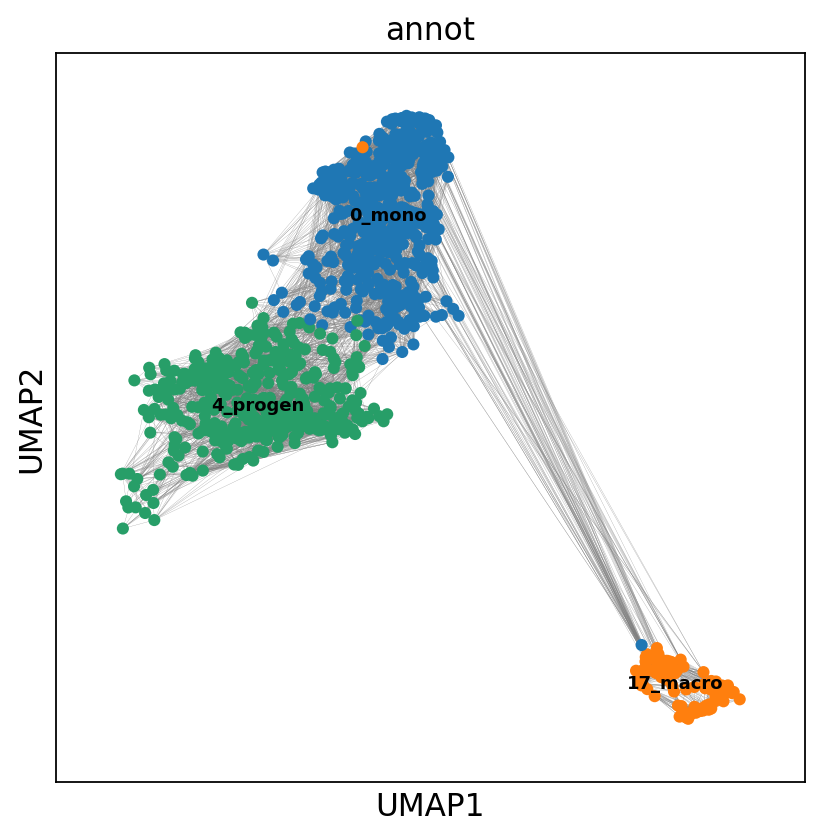

In [36]:
sc.pl.umap(adata, edges=True, color = 'annot', legend_loc= 'on data', legend_fontsize= 'xx-small')

running PAGA
    finished: added
    'paga/connectivities', connectivities adjacency (adata.uns)
    'paga/connectivities_tree', connectivities subtree (adata.uns) (0:00:00)
--> added 'pos', the PAGA positions (adata.uns['paga'])


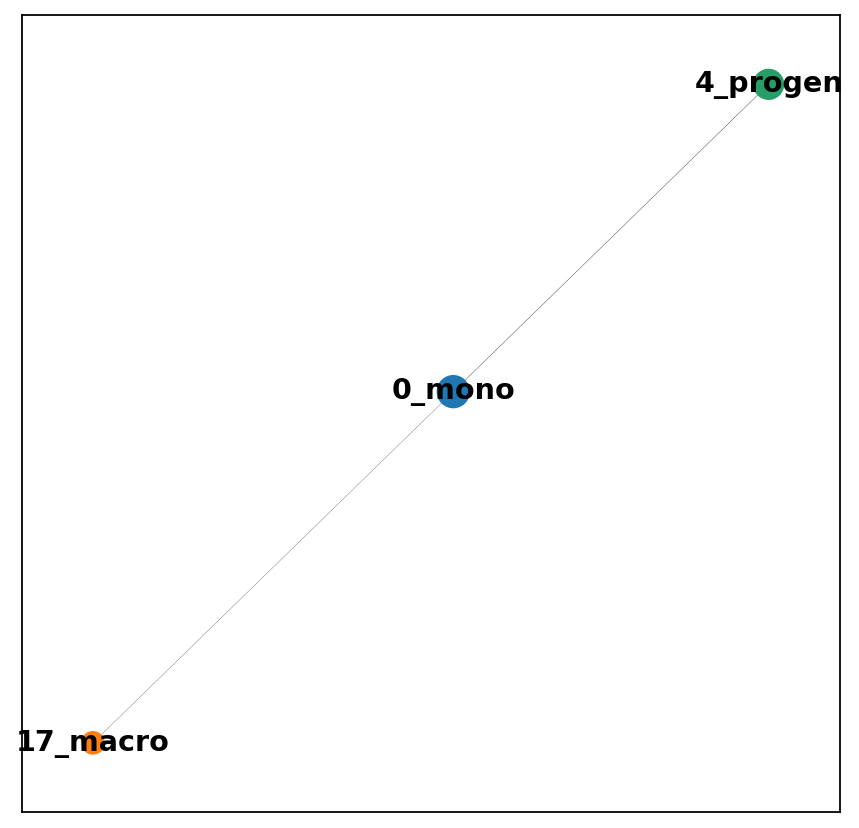

In [37]:
sc.tl.paga(adata, groups='annot')
sc.pl.paga(adata, color='annot', edge_width_scale = 0.3)

drawing single-cell graph using layout 'fa'
    finished: added
    'X_draw_graph_fr', graph_drawing coordinates (adata.obsm) (0:00:01)


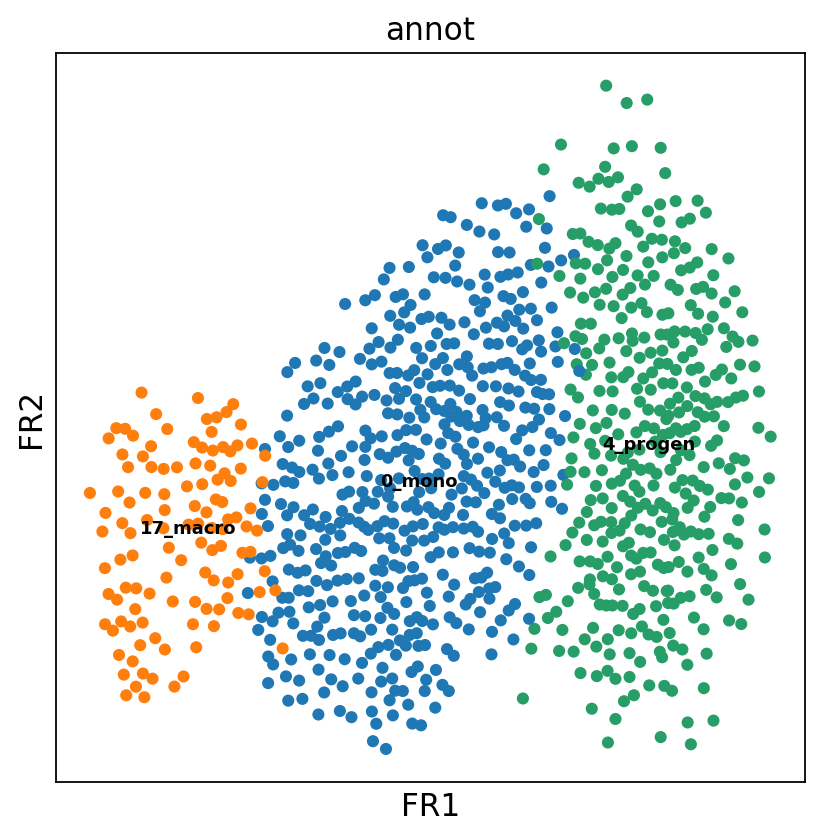

In [38]:
sc.tl.draw_graph(adata, init_pos='paga')
sc.pl.draw_graph(adata, color=['annot'], legend_loc='on data', legend_fontsize=  'xx-small')

In [47]:
adata.uns['iroot'] = np.flatnonzero(adata.obs['annot']  == '4_progen')[0]

sc.tl.dpt(adata)

computing Diffusion Pseudotime using n_dcs=10
    finished: added
    'dpt_pseudotime', the pseudotime (adata.obs) (0:00:00)


In [48]:
annot_new = adata.obs['annot'].copy()

annot_new = annot_new.str.replace(r'^\d+_', '', regex=True)  # 앞 번호 제거
mapping = {
    'mono': 'Monocyte',
    'macro': 'Macrophage',
    'progen': 'Progenitor',
}
annot_new = annot_new.map(mapping)

adata.obs['annotation'] = annot_new.astype('category')

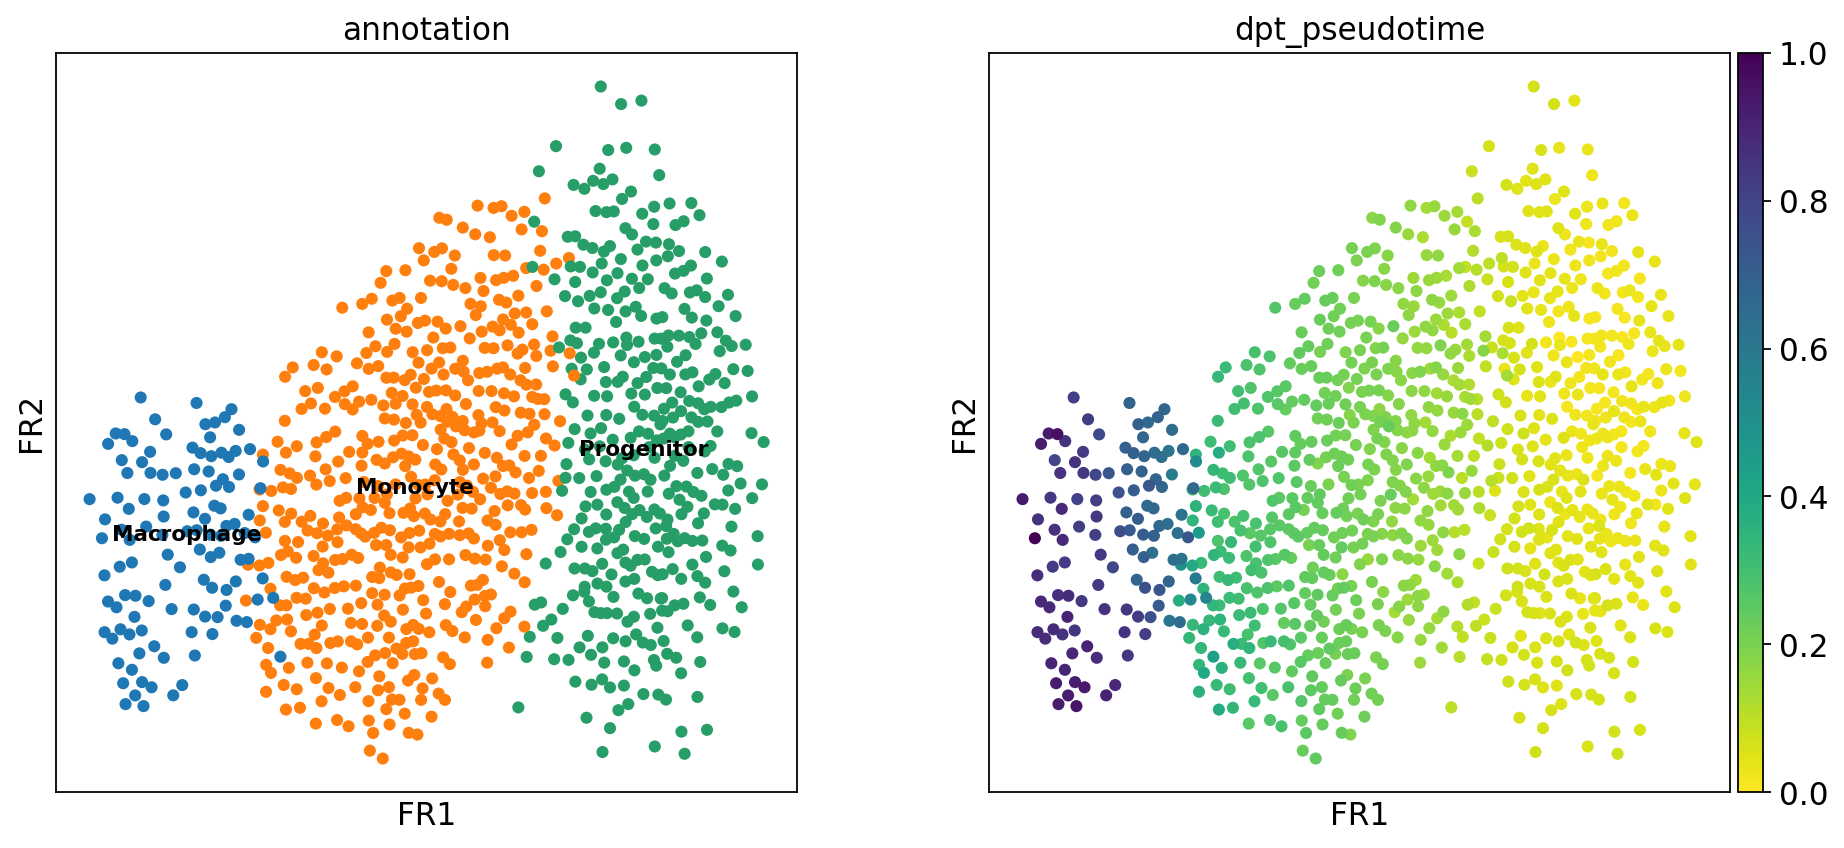

In [52]:
import scanpy as sc

sc.settings.set_figure_params(figsize=(6, 6))

sc.pl.draw_graph(
    adata,
    color=['annotation', 'dpt_pseudotime'],
    legend_loc='on data',
    legend_fontsize='x-small'
)

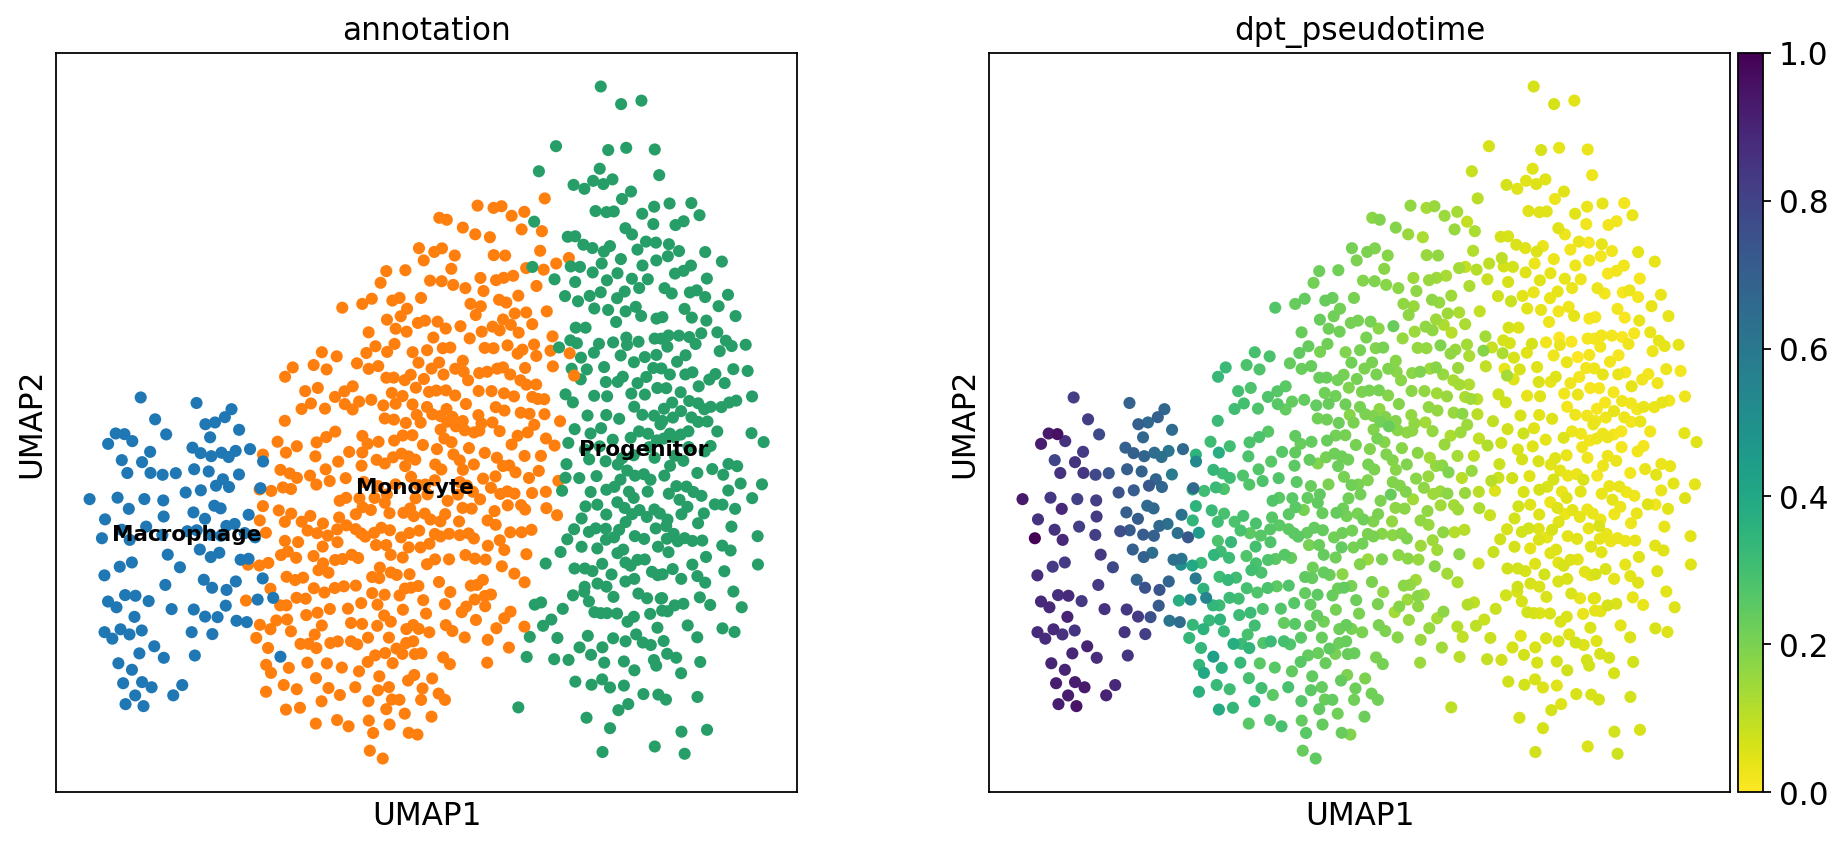

In [54]:
adata.obsm['X_umap_backup'] = adata.obsm['X_umap'].copy()

adata.obsm['X_umap'] = adata.obsm['X_draw_graph_fr'].copy()

sc.pl.umap(
    adata,
    color=['annotation', 'dpt_pseudotime'],
    legend_loc='on data',
    legend_fontsize='x-small'
)

In [55]:
import pandas as pd
import numpy as np

for col in adata.obs.columns:
    if pd.api.types.is_categorical_dtype(adata.obs[col]):
        if isinstance(adata.obs[col].cat.categories.values, pd.arrays.StringArray):
            adata.obs[col] = adata.obs[col].cat.rename_categories(
                adata.obs[col].cat.categories.astype('object')
            )
    elif isinstance(adata.obs[col].dtype, pd.StringDtype):
        adata.obs[col] = adata.obs[col].astype('object')

for col in adata.var.columns:
    if pd.api.types.is_categorical_dtype(adata.var[col]):
        if isinstance(adata.var[col].cat.categories.values, pd.arrays.StringArray):
            adata.var[col] = adata.var[col].cat.rename_categories(
                adata.var[col].cat.categories.astype('object')
            )
    elif isinstance(adata.var[col].dtype, pd.StringDtype):
        adata.var[col] = adata.var[col].astype('object')

adata.write("/home/Data_Drive_8TB/kykim/1. Oval/Cell_rank/test/adata_test.h5ad")